In [1]:
import pandas as pd
import requests

# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/children-born-per-woman.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/children-born-per-woman.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

In [2]:
df.head(3)

,entity,code,year,fertility_rate_hist
0,Afghanistan,AFG,1950,7.248
1,Afghanistan,AFG,1951,7.260
2,Afghanistan,AFG,1952,7.260


In [3]:
df.describe()

,year,fertility_rate_hist
count,19402.000000,19402.000000
mean,1985.861612,3.936123
std,22.049134,1.991179
min,1891.000000,0.662000
25%,1967.000000,2.138210
50%,1986.000000,3.466000
75%,2005.000000,5.849000
max,2023.000000,8.864000


In [6]:
mexico = df[df["entity"] == "Mexico"]
mexico.head()

,entity,code,year,fertility_rate_hist
11125,Mexico,MEX,1950,6.709
11126,Mexico,MEX,1951,6.727
11127,Mexico,MEX,1952,6.731
11128,Mexico,MEX,1953,6.734
11129,Mexico,MEX,1954,6.745


In [8]:
anios_mexico = mexico['year'].to_numpy()
tasa_fertilidad_mexico = mexico['fertility_rate_hist'].to_numpy()
 
japan = df[df["entity"] == "Japan"]
anios_japon = japan["year"].to_numpy()
tasa_fertilidad_japon = japan['fertility_rate_hist'].to_numpy()

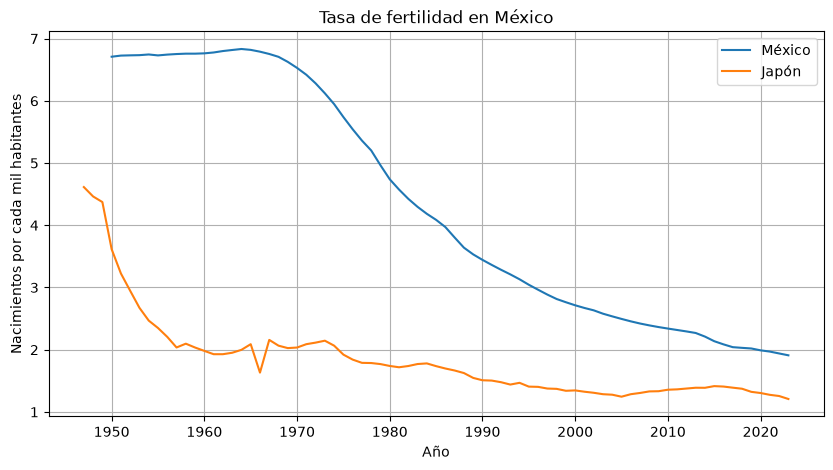

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
 
plt.plot(anios_mexico, tasa_fertilidad_mexico, label='México')
plt.plot(anios_japon, tasa_fertilidad_japon, label='Japón')
 
plt.title('Tasa de fertilidad en México')
plt.xlabel('Año')
plt.ylabel('Nacimientos por cada mil habitantes')
plt.grid(True)
plt.legend()
 
plt.show()

In [11]:
mascara_coincidencia_anios = anios_japon >= anios_mexico.min()

In [12]:
mascara_coincidencia_anios

array([False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [13]:
anios_japon_filtrados = anios_japon[mascara_coincidencia_anios]

In [14]:
tasa_japon_filtrada = tasa_fertilidad_japon[mascara_coincidencia_anios]
 

In [15]:
anios_japon.shape
 

(77,)

In [16]:
diferencia_ex_jp = tasa_fertilidad_mexico - tasa_japon_filtrada
 

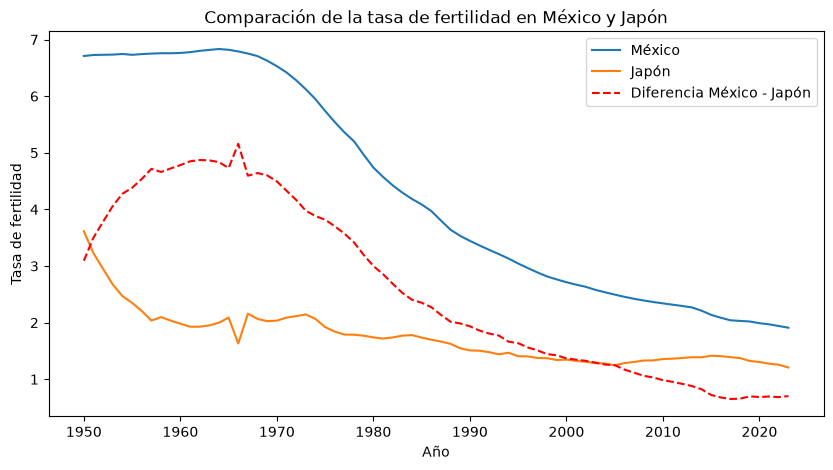

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(anios_mexico, tasa_fertilidad_mexico, label='México')
plt.plot(anios_japon_filtrados, tasa_japon_filtrada, label='Japón')
plt.plot(anios_mexico, diferencia_ex_jp, label='Diferencia México - Japón', linestyle='--', color='red')
 
plt.xlabel('Año')
plt.ylabel('Tasa de fertilidad')
plt.title('Comparación de la tasa de fertilidad en México y Japón')
plt.legend()
plt.show()